1/100
2/100
3/100
4/100
5/100
6/100
7/100
8/100
9/100
10/100
11/100
12/100
13/100
14/100
15/100
16/100
17/100
18/100
19/100
20/100
21/100
22/100
23/100
24/100
25/100
26/100
27/100
28/100
29/100
30/100
31/100
32/100
33/100
34/100
35/100
36/100
37/100
38/100
39/100
40/100
41/100
42/100
43/100
44/100
45/100
46/100
47/100
48/100
49/100
50/100
51/100
52/100
53/100
54/100
55/100
56/100
57/100
58/100
59/100
60/100
61/100
62/100
63/100
64/100
65/100
66/100
67/100
68/100
69/100
70/100
71/100
72/100
73/100
74/100
75/100
76/100
77/100
78/100
79/100
80/100
81/100
82/100
83/100
84/100
85/100
86/100
87/100
88/100
89/100
90/100
91/100
92/100
93/100
94/100
95/100
96/100
97/100
98/100
99/100
100/100


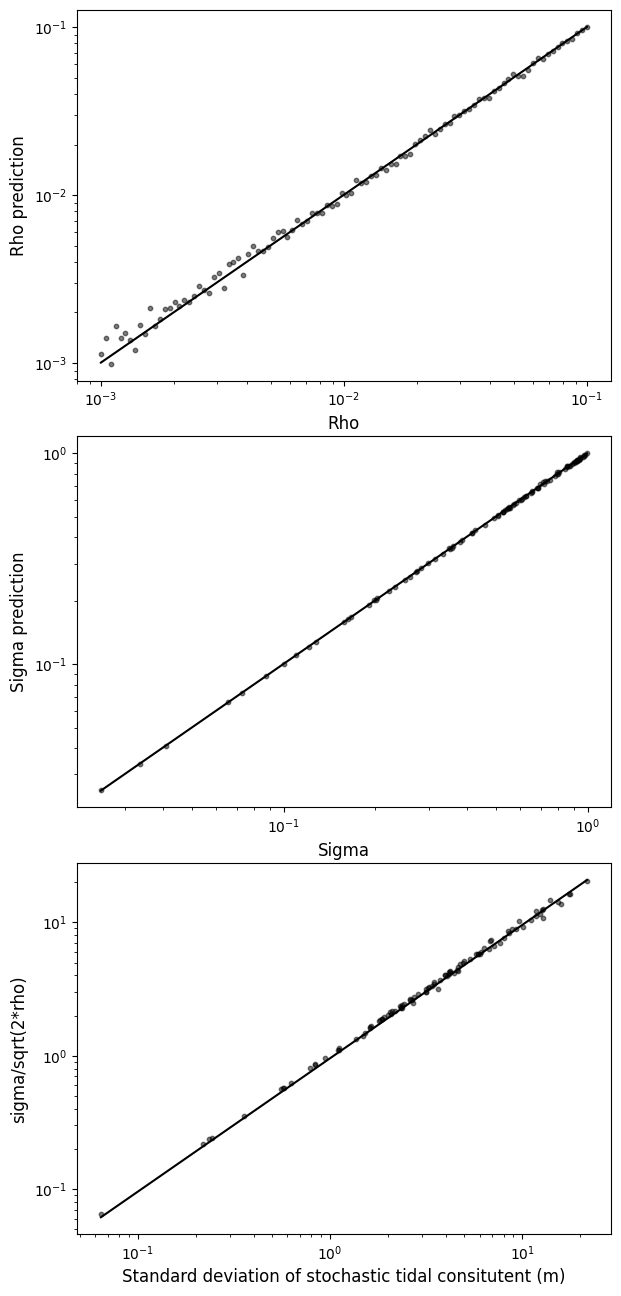

Rho prediction accuracy = [1.004]
Sigma prediction accuracy = [1.004]
Sigma_w = sigma / sqrt(2 rho), accuracy = [0.957]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def predict_stochastic_parameters():

    def generate_oun(nt, sigma = 1, rho = 0.1, dt = 1, xmean = 0):
        
        r = np.random.normal(size = nt)
        x = np.array([np.nan]*nt)
        x[0] = xmean
        for t in range(1, nt):
            x[t] = x[t - 1] + sigma*np.sqrt(dt)*r[t] + rho*(xmean - x[t - 1])*dt

        return x

    def estimate_stochastic_parameters(x, dt, xmean = 0):
        '''
        dx = sigma * np.sqrt(dt) * N(0,1) + rho * (xmean - x) * dt
        '''

        def linear_fit(x, a, b):
            return a + x*b

        dx = np.diff(x)
        residuals = dx - xmean

        # Predict rho
        par, _ = curve_fit(linear_fit, xdata = (xmean - x[:-1]), ydata = dx, p0=(0, 1))
        rho_est = par[1] / dt

        # Predict sigma
        sigma_est = np.std(residuals) / np.sqrt(dt)

        return rho_est, sigma_est

    n       = 100
    sigma   = np.random.random(size = n)
    rho     = 10**np.linspace(-3,-1, n)
    dt      = 10**np.linspace(-0.3,0.0, n)
    nt      = 100000

    rho_est   = np.array([np.nan]*n)
    sigma_est = np.array([np.nan]*n)
    w_std     = np.array([np.nan]*n)
    for i in range(n):

        w = generate_oun(nt, sigma = sigma[i], rho = rho[i], dt = dt[i])
        w_std[i] = w.std()
        rho_est[i], sigma_est[i] = estimate_stochastic_parameters(w, dt = dt[i])
        print(f'{i+1}/{n}')

    return rho, sigma, w_std, rho_est, sigma_est

def plot_figures(rho, sigma, w_std, rho_est, sigma_est):

    def scale_fit(x, a):
        return x*a

    rows, cols = 3,1
    fig = plt.figure(figsize=((6.4 + 0.5)*cols,(4.8 + 0.5)*rows))
    gs1 = fig.add_gridspec(rows,cols,hspace=.15, wspace=.15) #define subplot grid
    ax0 = fig.add_subplot(gs1[0,0])
    ax1 = fig.add_subplot(gs1[1,0])
    ax2 = fig.add_subplot(gs1[2,0])

    par_rho, _ = curve_fit(scale_fit, rho, rho_est, p0 = (1))
    xp = np.linspace(rho.min(), rho.max(), 100)
    yp = scale_fit(xp, *par_rho)
    ax0.plot(xp, yp, c = 'black')
    ax0.scatter(rho, rho_est, c = 'black', s = 10, alpha = 0.5)
    ax0.set_xscale('log')
    ax0.set_yscale('log')
    ax0.set_xlabel('Rho', fontsize = 12)
    ax0.set_ylabel('Rho prediction', fontsize = 12)
    
    par_sigma, _ = curve_fit(scale_fit, sigma, sigma_est, p0 = (1))
    xp = np.linspace(sigma.min(), sigma.max(), 100)
    yp = scale_fit(xp, *par_sigma)
    ax1.plot(xp, yp, c = 'black')
    ax1.scatter(sigma, sigma_est, c = 'black', s = 10, alpha = 0.5)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Sigma', fontsize = 12)
    ax1.set_ylabel('Sigma prediction', fontsize = 12)

    y = w_std
    x = sigma/np.sqrt(2*rho)
    par_pred, _ = curve_fit(scale_fit, x, y, p0 = (1))
    xp = np.linspace(x.min(), x.max(), 100)
    yp = scale_fit(xp, *par_pred)
    ax2.plot(xp, yp, c = 'black')
    ax2.scatter(x, y, c = 'black', s = 10, alpha = 0.5)
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel('Standard deviation of stochastic tidal consitutent (m)', fontsize = 12)
    ax2.set_ylabel('sigma/sqrt(2*rho)', fontsize = 12)

    plt.show()

    print(f'Rho prediction accuracy = {np.round(par_rho,3)}')
    print(f'Sigma prediction accuracy = {np.round(par_rho,3)}')
    print(f'Sigma_w = sigma / sqrt(2 rho), accuracy = {np.round(par_pred,3)}')

rho, sigma, w_std, rho_est, sigma_est = predict_stochastic_parameters()
plot_figures(rho, sigma, w_std, rho_est, sigma_est)